# The Climate is Changing: How is Our Sentiment?

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

### This is a notebook for extracting and exploring data from XML files. 

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

## Corpus Description

30 scientific articles are drawn from PeerJ's publications in the decade spanning 2013 to 2023 (10 from 2013, 10 from 2018, and 10 from 2023). Articles are filtered so as to have 30 or more citations, and are sorted by PeerJ's determination of relevance to the query "climate change." The top 10 most relevant articles per year, after meeting these described criteria, have then been chosen to comprise my corpus.

### Imports

In [47]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)


# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Creating DOC Table

In [48]:
# Downloading files 
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

# Iterate through files, grab XML info, and save to a dictionary
docs = []
for i, source_file_path in enumerate(source_files_paths):

    tree = etree.parse(source_file_path)
    root = tree.getroot()
    
    pub_id_str = root.xpath("//front//article-meta//article-id")[1].text

    title_el = root.xpath("//front//article-title")[0]
    title_str = " ".join([t.strip() for t in title_el.itertext()])

    year_str = root.xpath("//front//pub-date/year")[0].text
    month_str = root.xpath("//front//pub-date/month")[0].text
    day_str = root.xpath("//front//pub-date/day")[0].text
    date_str = "-".join([year_str, month_str, day_str])

    kwd_els = root.xpath("//kwd")
    kwd_strs = [kwd_el.text for kwd_el in kwd_els]

    p_els = root.xpath("//body//p")
    p_strs = []
    for p_el in p_els:
        etree.strip_elements(p_el, "xref", with_tail=False)
        p_str = etree.tostring(p_el, method="text", encoding="unicode")
        p_strs.append(p_str)
    
    docs.append({
        'doc_id': pub_id_str,
        'doc_title': title_str,
        'doc_date': date_str,
        'doc_content': " ".join(p_strs),
        'doc_kws': kwd_strs,
        'doc_file_path': source_file_path
    })

# Convert dictionary to data frame
DOC = pd.DataFrame(docs) 
del(docs)
DOC.head()

,doc_id,doc_title,doc_date,doc_content,doc_kws,doc_file_path
0,10.7717/peerj.5801,Agrichemicals and antibiotics in combination i...,2018-10-12,Neither reducing the use of antibiotics nor di...,"[Antibiotic resistance, Herbicide, Minimum sel...",sources\Agrichemicals_2018.xml
1,10.7717/peerj-cs.1306,Artificial intelligence-assisted air quality m...,2023-5-24,Our environment has been greatly impacted by r...,"[AI, Air quality monitoring, Smart cities, Sus...",sources\AI_air_2023.xml
2,10.7717/peerj.103,Real-time bioacoustics monitoring and automate...,2013-7-16,"Ecologists, conservation biologists, and park ...","[Acoustic monitoring, Machine learning, Animal...",sources\Bioacoustics_2013.xml
3,10.7717/peerj.15684,Biochar improves the growth and physiological ...,2023-8-18,Soil degradation in the Republic of Uzbekistan...,"[Salt stress, Biochar, Alfalfa, Amaranth, Maiz...",sources\Biochar_2023.xml
4,10.7717/peerj.15593,Biomes of the world under climate change scena...,2023-6-23,Climate change is one of the biggest threats t...,"[Climate change, Biomes, RCP scenarios, Machin...",sources\Biomes_2023.xml


In [49]:
# Save to CSV
DOC.to_csv("csvs/DOC/DOC.csv", index=True)

In [50]:
DOC['year'] = DOC['doc_date'].str[:4]
DOC['mth_day'] = DOC['doc_date'].str[5:]
DOC = DOC.copy()
DOC_to_join = DOC.drop(columns=['doc_id', 'doc_title', 'doc_date', 'doc_content', 'doc_kws', 'doc_file_path'])
DOC_to_join.index.rename('doc_id', inplace=True)
DOC_to_join.head()

,year,mth_day
doc_id,,
0,2018,10-12
1,2023,5-24
2,2013,7-16
3,2023,8-18
4,2023,6-23


### Creating SENTS Table

In [51]:
# Parse into Sentences with NLTK
SENTS = DOC.doc_content.apply(lambda x: pd.Series(nltk.sent_tokenize(x), dtype='string')).stack().to_frame('sent_str')
SENTS = SENTS.sent_str[SENTS.sent_str.apply(lambda x: isinstance(x, str))] # From Claude
SENTS.index.names = ['doc_id','sent_num']
SENTS = SENTS.to_frame()
SENTS.head()

sent_str
doc_id sent_num                                                   
0      0         Neither reducing the use of antibiotics nor di...
       1         This is because bacteria may be exposed to oth...
       2         Herbicides are examples of some of the most co...
       3         We previously showed that in some combinations...
       4         Here we demonstrate that in both cases the her...

In [52]:
# Saving to CSV
SENTS.to_csv("csvs/SENTS/SENTS.csv", index=True)

### Creating LIB Table

In [53]:
# Joining with DOC_to_join to be able to group by year
LIB = DOC.join(DOC_to_join, lsuffix='_L', rsuffix='_R')
LIB = LIB.drop(columns=['doc_id', 'doc_date', 'doc_kws',  'doc_file_path', 'mth_day_L', 'mth_day_R', 'year_R', 'doc_content'])
LIB.index.name = 'doc_id'

# Grouping SENTS df to obtain full doc content
SENTS_joined = SENTS.join(DOC_to_join)

# # Joining the two 
LIB = LIB.copy()
LIB = LIB.join(SENTS_joined)
LIB.groupby(LIB.index).agg(' '.join) # does not work - corrected by Claude below

LIB = LIB.groupby(level=0).agg({
    'doc_title': 'first',   # Same for all rows in a doc
    'year_L':    'first',
    'year':      'first',
    'mth_day':   'first',
    'sent_str':  ' '.join,  # Concatenate all sentences together
})


LIB['num_words'] = LIB['sent_str'].str.split().str.len() # From Claude

# Some extra cleanup
LIB.drop(columns=['year_L', 'mth_day'], inplace=True)

LIB.head()

,doc_title,year,sent_str,num_words
doc_id,,,,
0,Agrichemicals and antibiotics in combination i...,2018,Neither reducing the use of antibiotics nor di...,5515
1,Artificial intelligence-assisted air quality m...,2023,Our environment has been greatly impacted by r...,6765
2,Real-time bioacoustics monitoring and automate...,2013,"Ecologists, conservation biologists, and park ...",5738
3,Biochar improves the growth and physiological ...,2023,Soil degradation in the Republic of Uzbekistan...,3699
4,Biomes of the world under climate change scena...,2023,Climate change is one of the biggest threats t...,8721


In [54]:
# Saving to CSV
LIB.to_csv("csvs/LIB/LIB.csv", index=True)

### Visualization: Plotting Document Length

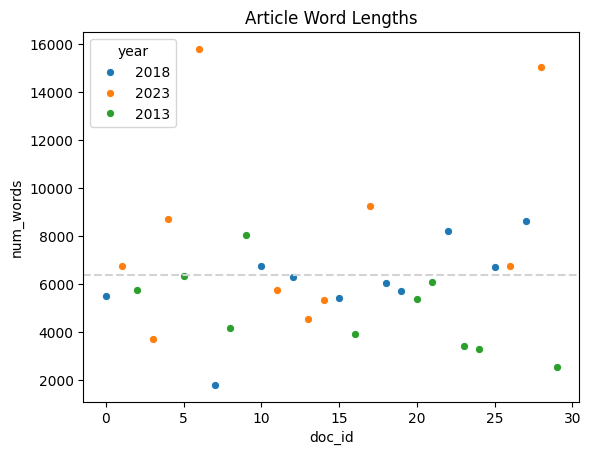

In [55]:
sns.lineplot(LIB, x='doc_id', y='num_words', hue=LIB['year'], marker='o',linestyle='')

# Add labels
ax = plt.gca() # Get the current axes

# Add the mean of the feature as dotted lines
ax.axhline(LIB.num_words.mean(), c='lightgray', ls='--')    

plt.title("Article Word Lengths")

plt.show()

Articles from 2013 and 2018 consistently fall below the mean, while articles from 2023 fall around and above the mean more often. This leads to a conclusion that articles are getting longer in 2023; perhaps this is due to increased pressure on scientists to "publish or perish" as the field inevitably becomes more competitive, or perhaps this is due to greater and greater dataset sizes available as satellites continue to gather data. It is of course possible that this small sample size means these data are just noise; future directions include expanding the corpus to see if these findings persist.

### Creating TOKENS Table

In [56]:
# Parse into Tokens with NLTK
TOKENS = SENTS.sent_str.apply(lambda x: pd.Series(nltk.pos_tag(nltk.word_tokenize(x)))).stack().to_frame('pos_tuple')
TOKENS = TOKENS.dropna()
TOKENS['pos'] = TOKENS.pos_tuple.apply(lambda x: x[1])
TOKENS['pos_group'] = TOKENS.pos.str[:2]
TOKENS['token_str'] = TOKENS.pos_tuple.apply(lambda x: x[0])
TOKENS = TOKENS.drop('pos_tuple', axis=1)
TOKENS['term_str'] = TOKENS.token_str.str.lower().str.replace(r"[\W_]+", "", regex=True) 
TOKENS = TOKENS[TOKENS.term_str != ''].copy()
TOKENS.index.names = SENTS.index.names + ['token_num']

TOKENS.head()

pos pos_group token_str  term_str
doc_id sent_num token_num                                   
0      0        0           CC        CC   Neither   neither
                1          VBG        VB  reducing  reducing
                2           DT        DT       the       the
                3           NN        NN       use       use
                4           IN        IN        of        of

In [57]:
TOKENS = TOKENS.join(DOC_to_join)
TOKENS = TOKENS.set_index('year', append=True)
TOKENS = TOKENS.set_index('mth_day', append=True)
TOKENS = TOKENS.reorder_levels([3,4,0,1,2])
TOKENS.head(30)

pos pos_group        token_str  \
year mth_day doc_id sent_num token_num                                   
2018 10-12   0      0        0           CC        CC          Neither   
                             1          VBG        VB         reducing   
                             2           DT        DT              the   
                             3           NN        NN              use   
                             4           IN        IN               of   
                             5          NNS        NN      antibiotics   
                             6           CC        CC              nor   
                             7           NN        NN        discovery   
                             8           IN        IN               of   
                             9           JJ        JJ              new   
                             10         NNS        NN             ones   
                             11          MD        MD              may   
                             12          VB        VB               be   
                             13          JJ        JJ       sufficient   
                             14         NNS        NN       strategies   
                             15          TO        TO               to   
                             16          VB        VB            avoid   
                             17          DT        DT              the   
                             18          JJ        JJ  post-antibiotic   
                             19          NN        NN              era   
                    1        0           DT        DT             This   
                             1          VBZ        VB               is   
                             2           IN        IN          because   
                             3          NNS        NN         bacteria   
                             4           MD        MD              may   
                             5           VB        VB               be   
                             6          VBN        VB          exposed   
                             7           TO        TO               to   
                             8           JJ        JJ            other   
                             9           JJ        JJ   non-antibiotic   

                                              term_str  
year mth_day doc_id sent_num token_num                  
2018 10-12   0      0        0                 neither  
                             1                reducing  
                             2                     the  
                             3                     use  
                             4                      of  
                             5             antibiotics  
                             6                     nor  
                             7               discovery  
                             8                      of  
                             9                     new  
                             10                   ones  
                             11                    may  
                             12                     be  
                             13             sufficient  
                             14             strategies  
                             15                     to  
                             16                  avoid  
                             17                    the  
                             18         postantibiotic  
                             19                    era  
                    1        0                    this  
                             1                      is  
                             2                 because  
                             3                bacteria  
                             4                     may  
                             5                      be  
                             6                 exposed  
                  

In [64]:
# Also known as CORPUS
CORPUS = TOKENS.copy()
print(len(CORPUS))

187356


In [59]:
# Saving to CSV
TOKENS.to_csv("csvs/TOKENS/TOKENS.csv", index=True)
CORPUS.to_csv("csvs/CORPUS/CORPUS.csv", index=True)

### Creating Keywords Table

In [60]:
DOCKW = DOC.doc_kws.apply(pd.Series).stack().to_frame('doc_kw')
DOCKW.index.names = ['doc_id', 'kw_num']
DOCKW.head()

doc_kw
doc_id kw_num                                 
0      0                 Antibiotic resistance
       1                             Herbicide
       2       Minimum selective concentration
       3                   Adaptive resistance
       4                             Evolution

In [61]:
KW = DOCKW.doc_kw.value_counts().to_frame('n')
KW.head()

,n
doc_kw,
Climate change,4
Machine learning,3
Symbiosis,3
Ecological niche modeling,2
Ocean acidification,2


### Create VOCAB Table

In [62]:
VOCAB = TOKENS.term_str.groupby(level='year').value_counts().to_frame('n')
VOCAB.index.name = 'term_str'
# Get overall probability (not as useful)
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
# Get information
VOCAB['i'] = -np.log2(VOCAB.p)
# Get information, probability per year
years = ['2013', '2018', '2023']
for year in years:
    mask = VOCAB.index.get_level_values('year') == year # Added by Claude
    year_n = VOCAB.loc[mask, 'n']
    VOCAB.loc[mask, 'p_yr'] = (year_n / year_n.sum()).values # Small Claude fixes
    VOCAB.loc[mask, 'i_yr'] = (-np.log2(year_n / year_n.sum())).values # From Claude
VOCAB

n         p          i      p_yr       i_yr
year term_str                                                
2013 the       3045  0.016252   5.943196  0.063549   3.975993
     of        1810  0.009661   6.693649  0.037774   4.726446
     and       1433  0.007649   7.030600  0.029907   5.063397
     in        1206  0.006437   7.279408  0.025169   5.312206
     to         967  0.005161   7.598051  0.020181   5.630848
...             ...       ...        ...       ...        ...
2023 consoles     1  0.000005  17.515423  0.000013  16.287604
     opt          1  0.000005  17.515423  0.000013  16.287604
     azure        1  0.000005  17.515423  0.000013  16.287604
     console      1  0.000005  17.515423  0.000013  16.287604
     xbox         1  0.000005  17.515423  0.000013  16.287604

[21582 rows x 5 columns]

In [63]:
# Saving to CSV
VOCAB.to_csv("csvs/VOCAB/VOCAB.csv", index=True)